#
# **<center>UAS Machine Learning Project: Analisis Perbandingan Algoritma Random Forest Regression dan XGBoost untuk Prediksi Daya Panel Surya Berdasarkan Data Meteorologi pada Wilayah 3T di Indonesia</center>**

# Kelompok 4:
Ketua: Rafael Hartono (24031554166)

Anggota 1: Athiyyatus Salisah (24031554223)

Anggota 2: Nurul Aini (24031554060)



# Link Code:
https://colab.research.google.com/drive/1knzbM4JPs0anvtSVLee2vCKiaVz52mEf?authuser=1

# 0. Set up library

In [1]:
# scraping
import requests
import pandas as pd
import time
import os


# download file from drive
import gdown

# viualization
import seaborn as sns
import matplotlib.pyplot as plt

# calculation
import numpy as np

import joblib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

import statsmodels.api as sm
from statsmodels.formula.api import ols

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import gc

# 1. Load Data

## Scrapping data from web

In [2]:
# locations = {

#     # ACEH
#     "Simeulue": (2.6167, 96.0833),
#     "Aceh Singkil": (2.2875, 97.7889),

#     # SUMATERA UTARA
#     "Nias": (1.0333, 97.7667),
#     "Nias Selatan": (0.5833, 97.8333),
#     "Nias Barat": (1.0000, 97.5000),
#     "Nias Utara": (1.2500, 97.6000),

#     # SUMATERA BARAT
#     "Kepulauan Mentawai": (-2.1333, 99.5000),

#     # KEPULAUAN RIAU
#     "Natuna": (3.9500, 108.3833),
#     "Kepulauan Anambas": (3.1053, 106.6206),

#     # KALIMANTAN BARAT
#     "Kapuas Hulu": (0.8333, 112.9333),

#     # KALIMANTAN TIMUR
#     "Mahakam Ulu": (0.5000, 115.5000),

#     # KALIMANTAN UTARA
#     "Malinau": (3.5844, 116.6478),
#     "Nunukan": (4.1333, 117.6667),

#     # SULAWESI UTARA
#     "Kepulauan Sangihe": (3.5000, 125.5000),
#     "Kepulauan Talaud": (4.2500, 126.7833),

#     # SULAWESI TENGAH
#     "Tojo Una-Una": (-1.2167, 121.4833),

#     # SULAWESI TENGGARA
#     "Wakatobi": (-5.3167, 123.5500),

#     # NUSA TENGGARA TIMUR
#     "Sumba Barat": (-9.5333, 119.3667),
#     "Sumba Tengah": (-9.4167, 119.6333),
#     "Sumba Barat Daya": (-9.5667, 119.0500),
#     "Sumba Timur": (-9.6500, 120.2667),
#     "Alor": (-8.3000, 124.5667),
#     "Lembata": (-8.3833, 123.4000),
#     "Rote Ndao": (-10.7333, 123.0667),
#     "Sabu Raijua": (-10.5000, 121.8333),
#     "Timor Tengah Selatan": (-9.8500, 124.2833),
#     "Timor Tengah Utara": (-9.4333, 124.4833),
#     "Belu": (-9.0167, 124.9500),
#     "Malaka": (-9.5667, 124.9000),

#     # MALUKU
#     "Maluku Barat Daya": (-7.5000, 126.0000),
#     "Kepulauan Aru": (-6.1947, 134.5500),
#     "Seram Bagian Timur": (-3.0000, 130.0000),
#     "Buru Selatan": (-3.7000, 126.7000),
#     "Kepulauan Tanimbar": (-7.9667, 131.3000),

#     # MALUKU UTARA
#     "Pulau Morotai": (2.3333, 128.5000),

#     # PAPUA SELATAN
#     "Merauke": (-8.4932, 140.4018),
#     "Mappi": (-7.0000, 139.0000),
#     "Asmat": (-5.0833, 138.0833),
#     "Boven Digoel": (-6.1000, 140.3000),

#     # PAPUA PEGUNUNGAN
#     "Jayawijaya": (-4.0833, 138.9500),
#     "Yahukimo": (-4.0833, 139.5000),
#     "Pegunungan Bintang": (-4.5000, 140.4000),
#     "Tolikara": (-3.4833, 138.4667),
#     "Lanny Jaya": (-3.9167, 138.4167),
#     "Nduga": (-4.4000, 138.1000),
#     "Mamberamo Tengah": (-3.6167, 138.3000),
#     "Yalimo": (-3.7167, 139.5833),

#     # PAPUA TENGAH
#     "Puncak": (-3.9833, 137.6333),
#     "Puncak Jaya": (-3.7000, 137.0000),
#     "Mimika": (-4.5470, 136.8874),
#     "Dogiyai": (-4.0167, 135.7500),
#     "Deiyai": (-4.0833, 136.0833),
#     "Intan Jaya": (-3.5000, 136.7000),

#     # PAPUA
#     "Waropen": (-2.3000, 136.6000),
#     "Mamberamo Raya": (-2.5333, 137.9667),
#     "Supiori": (-0.7500, 135.6333),

#     # PAPUA BARAT DAYA
#     "Tambrauw": (-0.7500, 132.0833),
#     "Maybrat": (-1.3333, 132.2500),
#     "Raja Ampat": (-0.2333, 130.5167),
# }

# # LIST PENAMPUNG DATA
# all_data = []

# # LOOP SETIAP KOTA
# for city, (lat, lon) in locations.items():

#     print(f"Mengambil data {city}...")

#     url = (
#         f"https://re.jrc.ec.europa.eu/api/v5_2/seriescalc?"
#         f"lat={lat}"
#         f"&lon={lon}"
#         f"&startyear=2015"
#         f"&endyear=2020"
#         f"&outputformat=json"
#         f"&pvcalculation=1"
#         f"&peakpower=1"
#         f"&loss=14"
#         f"&trackingtype=0"
#         f"&optimalinclination=1"
#         f"&optimalangles=1"
#     )

#     response = requests.get(url)

#     if response.status_code != 200:
#         print(f"Gagal mengambil data {city}. Status code: {response.status_code}. Response: {response.text}")
#         continue

#     data = response.json()

#     try:
#         hourly_data = data["outputs"]["hourly"]

#         df_city = pd.DataFrame(hourly_data)

#         df_city["City"] = city

#         all_data.append(df_city)

#         print(f"Berhasil: {city}")

#     except Exception as e:
#         print(f"Format data error pada {city}: {e}")

#     time.sleep(1)

# # GABUNG SEMUA DATA
# if not all_data:
#     print("Tidak ada data yang berhasil diambil dari API untuk digabungkan.")
# else:
#     df = pd.concat(all_data, ignore_index=True)

#     # RENAME KOLOM
#     df.rename(columns={
#         "time": "Datetime",
#         "G(i)": "SolarIrradiance",
#         "H_sun": "SunHeight",
#         "T2m": "Temperature",
#         "WS10m": "WindSpeed",
#         "P": "PowerOutput"
#     }, inplace=True)

#     # SIMPAN CSV
#     filename = "pvgis_indonesia_energy.csv"

#     df.to_csv(filename, index=False)

#     # INFO DATASET
#     print("\nDataset berhasil disimpan")
#     print("Nama file:", filename)

#     print("\nJumlah data:", len(df))
#     print("Jumlah kolom:", len(df.columns))

#     print("\n5 Data Pertama")
#     print(df.head())

## Download Scrapped Data

In [3]:
gdown.download(id='1spubCd2Oeay12auAHAZqOxV5eiXL2SwR')

filename = "pvgis_indonesia_energy.csv"

size_mb = os.path.getsize(filename) / (1024 * 1024)

print(f"Ukuran file: {size_mb:.2f} MB")

df = pd.read_csv(filename,dtype={
    'SolarIrradiance': 'float32',
    'SunHeight': 'float32',
    'Temperature': 'float32',
    'WindSpeed': 'float32',
    'PowerOutput': 'float32',
    'City': 'category' })




Downloading...
From (original): https://drive.google.com/uc?id=1spubCd2Oeay12auAHAZqOxV5eiXL2SwR
From (redirected): https://drive.google.com/uc?id=1spubCd2Oeay12auAHAZqOxV5eiXL2SwR&confirm=t&uuid=92743e7c-e0f6-4e18-b604-327c579fa693
To: /content/pvgis_indonesia_energy.csv
100%|██████████| 123M/123M [00:01<00:00, 98.8MB/s]


Ukuran file: 116.90 MB


#2. Exploration Data Analysis

## Raw Data

In [4]:
df

,Datetime,PowerOutput,SolarIrradiance,SunHeight,Temperature,WindSpeed,Int,City
0,20150101:0030,35.860001,62.889999,10.650000,26.170000,3.10,0.0,Simeulue
1,20150101:0130,108.000000,153.559998,24.200001,26.480000,3.24,0.0,Simeulue
2,20150101:0230,247.850006,321.799988,37.310001,26.549999,3.38,0.0,Simeulue
3,20150101:0330,281.459991,363.019989,49.430000,26.980000,3.17,0.0,Simeulue
4,20150101:0430,278.470001,362.799988,59.340000,27.110001,2.83,0.0,Simeulue
...,...,...,...,...,...,...,...,...
2209531,20201231:1930,0.000000,0.000000,0.000000,22.540001,0.34,0.0,Tambrauw
2209532,20201231:2030,0.000000,0.000000,0.000000,22.850000,0.00,0.0,Tambrauw
2209533,20201231:2130,3.510000,13.550000,3.850000,22.480000,0.41,0.0,Tambrauw
2209534,20201231:2230,3.510000,13.550000,17.610001,22.760000,0.55,0.0,Tambrauw


## Data Type

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209536 entries, 0 to 2209535
Data columns (total 8 columns):
 #   Column           Dtype   
---  ------           -----   
 0   Datetime         object  
 1   PowerOutput      float32 
 2   SolarIrradiance  float32 
 3   SunHeight        float32 
 4   Temperature      float32 
 5   WindSpeed        float32 
 6   Int              float64 
 7   City             category
dtypes: category(1), float32(5), float64(1), object(1)
memory usage: 78.0+ MB


In [6]:
df["Datetime"] = pd.to_datetime(df["Datetime"], format="%Y%m%d:%H%M")


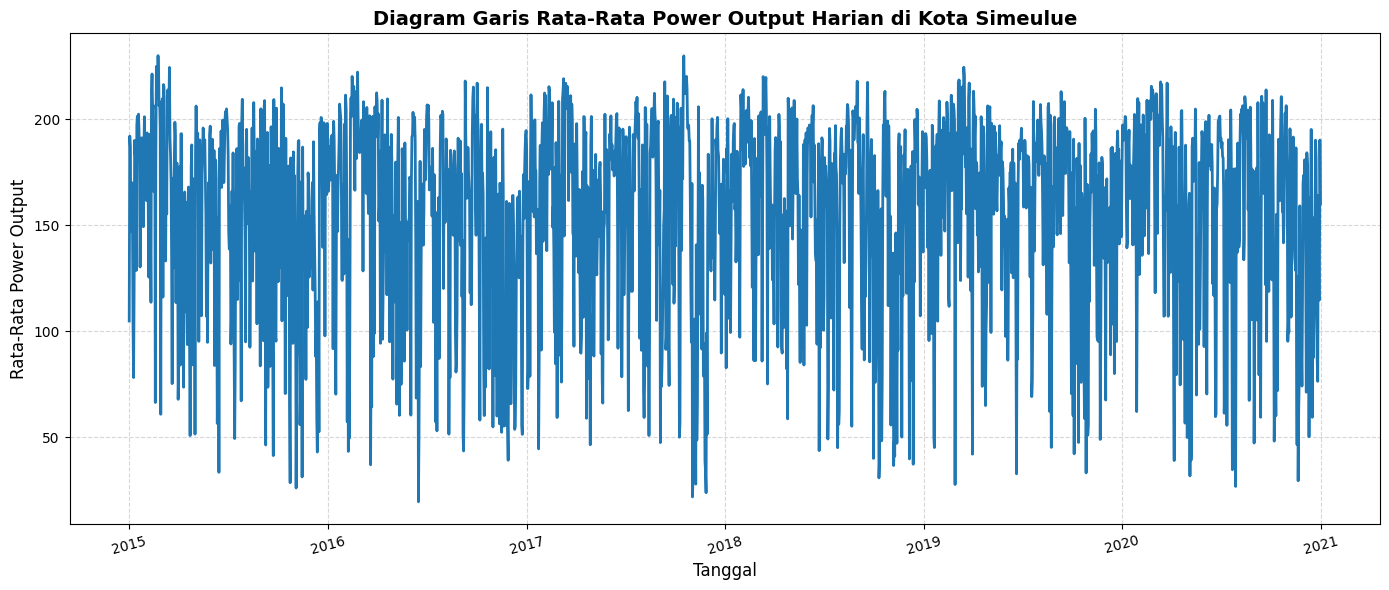

In [7]:
nama_kota = "Simeulue"
df_kota = df[df["City"] == nama_kota].copy()
df_kota['Datetime'] = pd.to_datetime(df_kota['Datetime'], format="%Y%m%d:%H%M")
df_kota = df_kota.set_index("Datetime")

df_harian = df_kota[["PowerOutput"]].resample("D").mean().reset_index()


plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_harian,
    x="Datetime",
    y="PowerOutput",
    color="#1f77b4",
    linewidth=2,
)

plt.title(
    f"Diagram Garis Rata-Rata Power Output Harian di Kota {nama_kota}",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Tanggal", fontsize=12)
plt.ylabel("Rata-Rata Power Output", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Delete Datetime

In [8]:
df = df.drop('Datetime', axis=1)
df

,PowerOutput,SolarIrradiance,SunHeight,Temperature,WindSpeed,Int,City
0,35.860001,62.889999,10.650000,26.170000,3.10,0.0,Simeulue
1,108.000000,153.559998,24.200001,26.480000,3.24,0.0,Simeulue
2,247.850006,321.799988,37.310001,26.549999,3.38,0.0,Simeulue
3,281.459991,363.019989,49.430000,26.980000,3.17,0.0,Simeulue
4,278.470001,362.799988,59.340000,27.110001,2.83,0.0,Simeulue
...,...,...,...,...,...,...,...
2209531,0.000000,0.000000,0.000000,22.540001,0.34,0.0,Tambrauw
2209532,0.000000,0.000000,0.000000,22.850000,0.00,0.0,Tambrauw
2209533,3.510000,13.550000,3.850000,22.480000,0.41,0.0,Tambrauw
2209534,3.510000,13.550000,17.610001,22.760000,0.55,0.0,Tambrauw


## Nan Detection

In [9]:
df.isna().sum()

,0
PowerOutput,0
SolarIrradiance,0
SunHeight,0
Temperature,0
WindSpeed,0
Int,0
City,0


## Data Distribution each city

In [10]:
df['City'].value_counts()

,count
City,
Nias,52608
Simeulue,52608
Nias Selatan,52608
Nias Barat,52608
Nias Utara,52608
Mahakam Ulu,52608
Malinau,52608
Nunukan,52608
Kepulauan Sangihe,52608


## Describe Stats

In [11]:
df.describe()

,PowerOutput,SolarIrradiance,SunHeight,Temperature,WindSpeed,Int
count,2.209536e+06,2.209536e+06,2.209536e+06,2.209536e+06,2.209536e+06,2209536.0
mean,1.179557e+02,1.584686e+02,2.048801e+01,2.406028e+01,1.855421e+00,0.0
std,1.856387e+02,2.442016e+02,2.637811e+01,4.314576e+00,2.086241e+00,0.0
min,0.000000e+00,0.000000e+00,-7.380000e+00,3.520000e+00,0.000000e+00,0.0
25%,0.000000e+00,0.000000e+00,0.000000e+00,2.236000e+01,6.200000e-01,0.0
50%,2.500000e-01,6.540000e+00,3.400000e-01,2.504000e+01,1.240000e+00,0.0
75%,1.672100e+02,2.268500e+02,4.241000e+01,2.692000e+01,2.480000e+00,0.0
max,8.348900e+02,1.123690e+03,8.994000e+01,4.120000e+01,3.779000e+01,0.0


## Delete int

In [12]:
df = df.drop('Int', axis=1)
df

,PowerOutput,SolarIrradiance,SunHeight,Temperature,WindSpeed,City
0,35.860001,62.889999,10.650000,26.170000,3.10,Simeulue
1,108.000000,153.559998,24.200001,26.480000,3.24,Simeulue
2,247.850006,321.799988,37.310001,26.549999,3.38,Simeulue
3,281.459991,363.019989,49.430000,26.980000,3.17,Simeulue
4,278.470001,362.799988,59.340000,27.110001,2.83,Simeulue
...,...,...,...,...,...,...
2209531,0.000000,0.000000,0.000000,22.540001,0.34,Tambrauw
2209532,0.000000,0.000000,0.000000,22.850000,0.00,Tambrauw
2209533,3.510000,13.550000,3.850000,22.480000,0.41,Tambrauw
2209534,3.510000,13.550000,17.610001,22.760000,0.55,Tambrauw


# 3. Spliting

## Menentukan fitur dan target

In [13]:
X = df[[
    'SolarIrradiance',
    'SunHeight',
    'Temperature',
    'WindSpeed',
    'City'
]]

y = df['PowerOutput']


## Spliting

In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [15]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1767628 entries, 751448 to 1692743
Data columns (total 5 columns):
 #   Column           Dtype   
---  ------           -----   
 0   SolarIrradiance  float32 
 1   SunHeight        float32 
 2   Temperature      float32 
 3   WindSpeed        float32 
 4   City             category
dtypes: category(1), float32(4)
memory usage: 42.1 MB


In [16]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 441908 entries, 1118566 to 702480
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   SolarIrradiance  441908 non-null  float32 
 1   SunHeight        441908 non-null  float32 
 2   Temperature      441908 non-null  float32 
 3   WindSpeed        441908 non-null  float32 
 4   City             441908 non-null  category
dtypes: category(1), float32(4)
memory usage: 10.5 MB


# 4. Feature Engginering & Correlation

## Label Encoding

In [17]:
le = LabelEncoder()

X_train['City'] = le.fit_transform(X_train['City'])

X_test['City'] = le.transform(X_test['City'])

In [18]:
X_train

,SolarIrradiance,SunHeight,Temperature,WindSpeed,City
751448,149.649994,20.030001,27.330000,4.07,34
1224566,0.000000,0.000000,24.280001,1.66,29
1664511,0.000000,0.000000,14.200000,0.41,24
1793005,0.000000,0.000000,15.530000,0.21,14
188589,0.000000,0.000000,24.100000,0.62,20
...,...,...,...,...,...
2003274,0.000000,0.000000,21.240000,0.69,17
1570006,139.850006,25.480000,24.790001,0.69,3
732180,0.000000,0.000000,25.770000,1.86,32
110268,0.000000,0.000000,26.580000,3.79,21


## Pair Plot

In [19]:
cat = ['City']
X_train_cat = X_train[cat]
X_train_num = X_train.drop(cat, axis=1)

X_train_cat.head()

,City
751448,34
1224566,29
1664511,24
1793005,14
188589,20


In [20]:
X_train_num.head()

,SolarIrradiance,SunHeight,Temperature,WindSpeed
751448,149.649994,20.030001,27.330000,4.07
1224566,0.000000,0.000000,24.280001,1.66
1664511,0.000000,0.000000,14.200000,0.41
1793005,0.000000,0.000000,15.530000,0.21
188589,0.000000,0.000000,24.100000,0.62


In [21]:
df_num = pd.concat([X_train_num, y_train], axis=1)

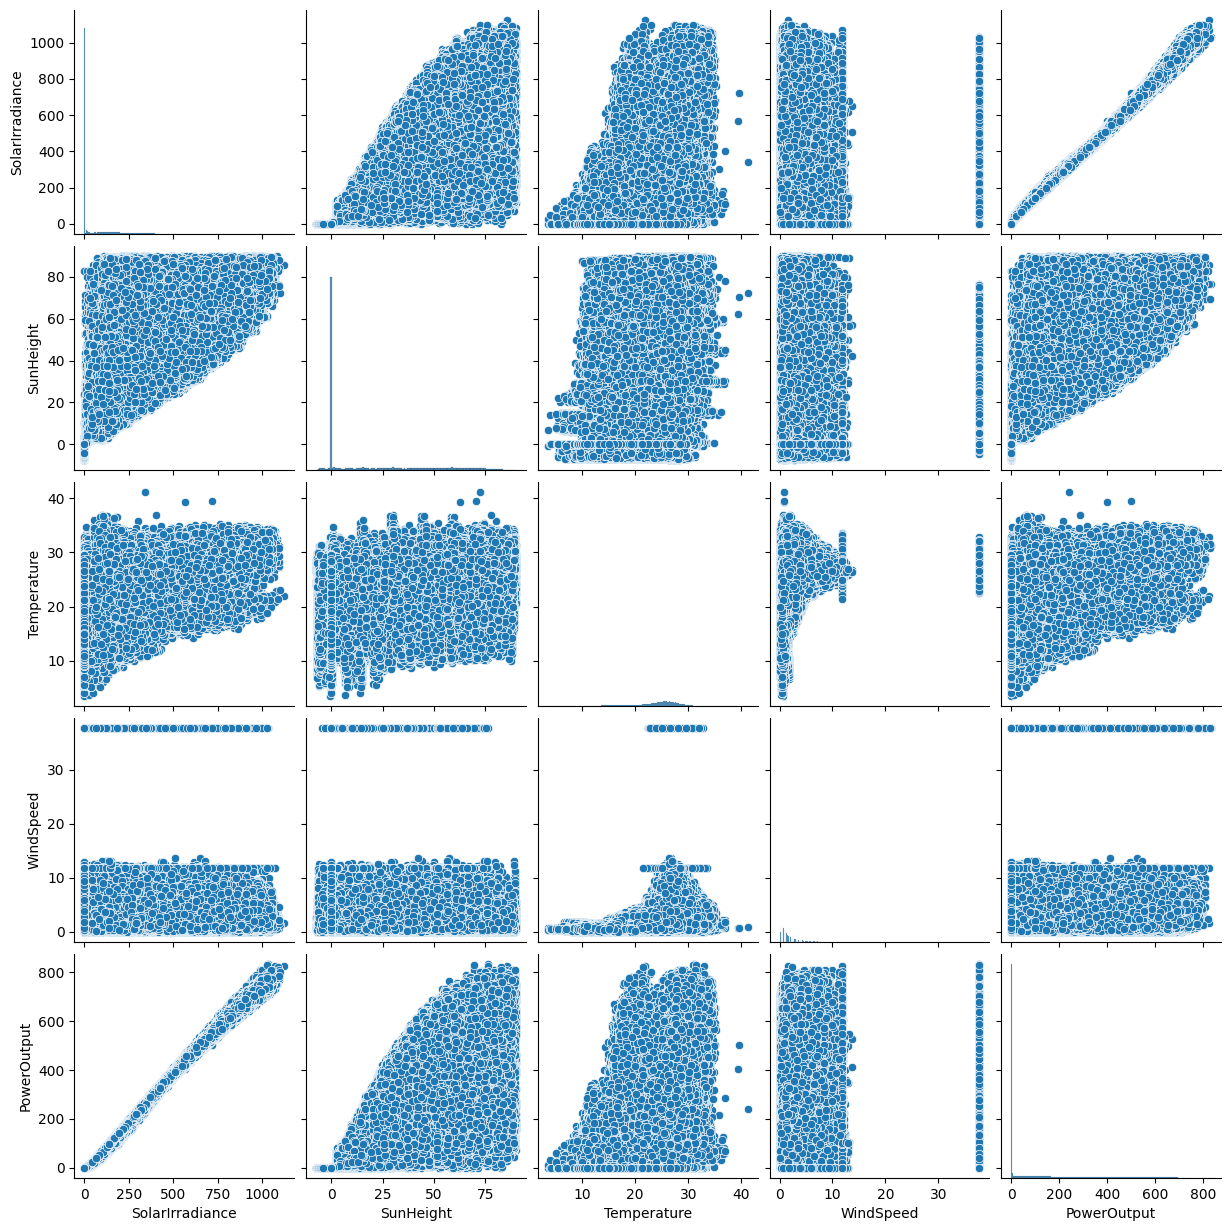

In [22]:
sns.pairplot(df_num)
plt.show()

## Pearson Correlation

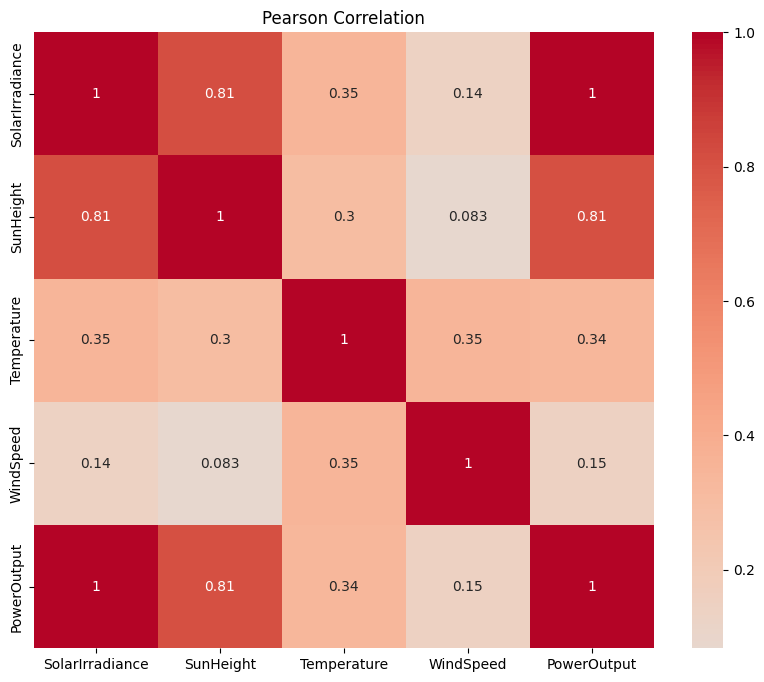

In [23]:
df_corr = df_num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, center=0, cmap='coolwarm')
plt.title('Pearson Correlation')
plt.show()

## Anova

In [24]:
df_cat = pd.concat([X_train_cat, y_train], axis=1)


formula = 'PowerOutput ~ C(City)'
model_anova = ols(formula, data=df_cat).fit()

anova_table = sm.stats.anova_lm(model_anova, typ=2)

print("=== HASIL UJI ANOVA ===")
print(anova_table)


p_value = anova_table['PR(>F)'].iloc[0]

print("\n=== KESIMPULAN === ")
if p_value < 0.05:
    print(f"P-Value = {p_value:.5f} (< 0.05)")
    print("Ada HUBUNGAN SIGNIFIKAN antara Kota dan Power Output.")
    print("Rata-rata daya yang dihasilkan berbeda secara nyata di tiap kota. Fitur 'City' LAYAK DIPERTAHANKAN.")
else:
    print(f"P-Value = {p_value:.5f} (>= 0.05)")
    print("TIDAK ADA HUBUNGAN SIGNIFIKAN antara Kota dan Power Output.")
    print("Perbedaan kota tidak memengaruhi hasil daya. Fitur 'City' bisa dipertimbangkan untuk dibuang.")

=== HASIL UJI ANOVA ===
                sum_sq         df            F  PR(>F)
C(City)   5.646665e+09       41.0  4387.334835     0.0
Residual  5.548658e+10  1767586.0          NaN     NaN

=== KESIMPULAN === 
P-Value = 0.00000 (< 0.05)
Ada HUBUNGAN SIGNIFIKAN antara Kota dan Power Output.
Rata-rata daya yang dihasilkan berbeda secara nyata di tiap kota. Fitur 'City' LAYAK DIPERTAHANKAN.


/tmp/ipykernel_21676/4166982830.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='City', y='PowerOutput', data=df_cat, palette='Set2')


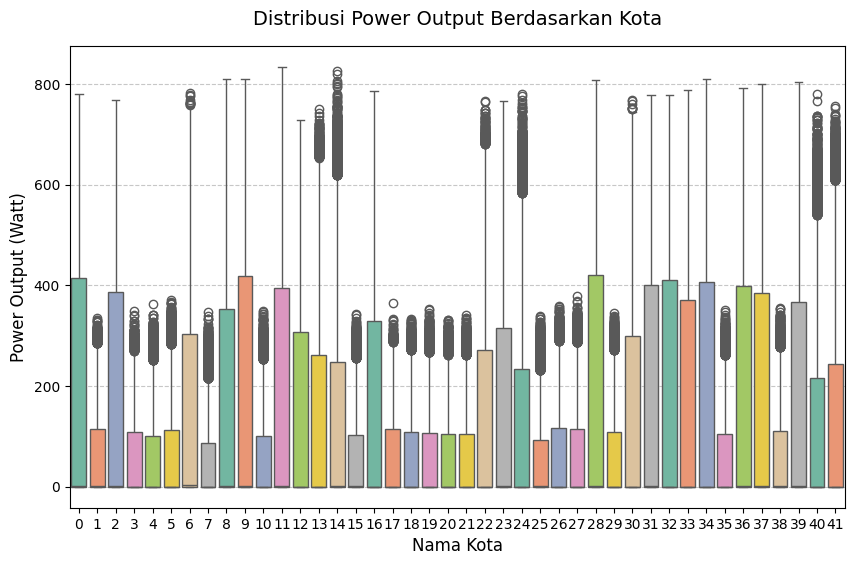

In [25]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='City', y='PowerOutput', data=df_cat, palette='Set2')

plt.title('Distribusi Power Output Berdasarkan Kota', fontsize=14, pad=15)
plt.xlabel('Nama Kota', fontsize=12)
plt.ylabel('Power Output (Watt)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## PCA

In [26]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)

pca_penuh = PCA(n_components=4, random_state=42)
pca_penuh.fit(X_train_scaled)

X_train_pca = pca_penuh.transform(X_train_scaled)

eigenvalues = pca_penuh.explained_variance_

print("=== HASIL EKSTRAKSI EIGENVALUE ===")
for i, ev in enumerate(eigenvalues):
    print(f"PC{i+1}: {ev:.4f}")

n_komponen_terpilih = np.sum(eigenvalues > 1)

print(f"\nJumlah PC yang memiliki Eigenvalue > 1: {n_komponen_terpilih} Komponen")
print("\n=== HASIL EKSTRAKSI PCA ===")
X_train_pca_terpilih = X_train_pca[:, :n_komponen_terpilih]
X_train_pca_df = pd.DataFrame(X_train_pca_terpilih, index=X_train_cat.index, columns=[f'PC{i+1}' for i in range(X_train_pca_terpilih.shape[1])])


print(X_train_pca_df)

=== HASIL EKSTRAKSI EIGENVALUE ===
PC1: 2.0991
PC2: 1.1115
PC3: 0.6033
PC4: 0.1861

Jumlah PC yang memiliki Eigenvalue > 1: 2 Komponen

=== HASIL EKSTRAKSI PCA ===
              PC1       PC2
751448   0.586320  1.164662
1224566 -0.861609  0.428106
1664511 -2.055780 -1.077790
1793005 -1.944600 -1.011999
188589  -1.012285  0.030587
...           ...       ...
2003274 -1.297131 -0.242024
1570006 -0.005737 -0.394733
732180  -0.683155  0.656249
110268  -0.354652  1.443563
1692743 -0.497078 -1.163939

[1767628 rows x 2 columns]


In [27]:
X_train_pca_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1767628 entries, 751448 to 1692743
Data columns (total 2 columns):
 #   Column  Dtype  
---  ------  -----  
 0   PC1     float32
 1   PC2     float32
dtypes: float32(2)
memory usage: 27.0 MB


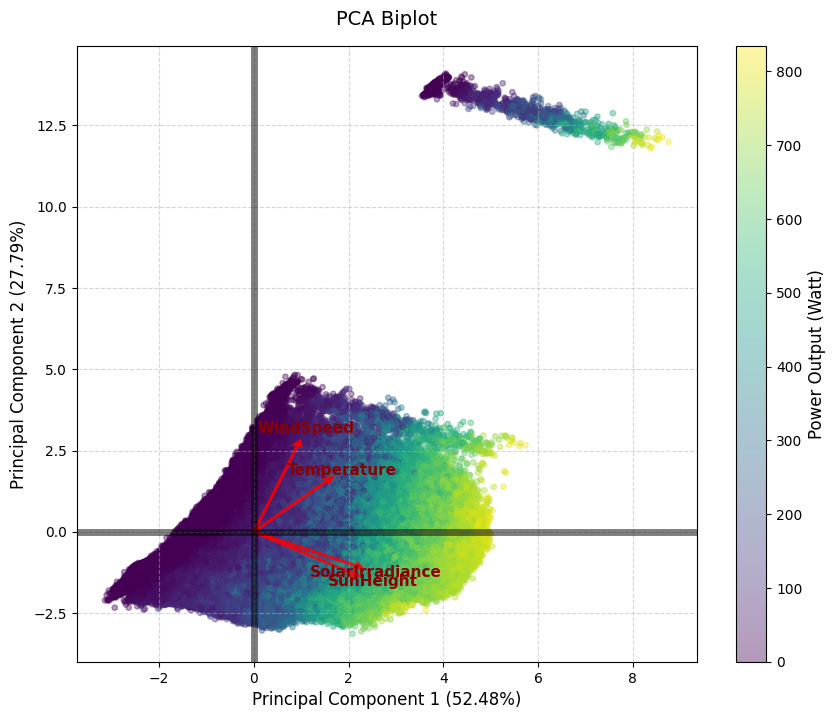

In [28]:
loadings = pca_penuh.components_

plt.figure(figsize=(10, 8))

scatter = plt.scatter(X_train_pca_df['PC1'], X_train_pca_df['PC2'],
                      c=y_train.values, cmap='viridis', alpha=0.4, s=15)

cbar = plt.colorbar(scatter)
cbar.set_label('Power Output (Watt)', fontsize=12)

skala_panah = 3.5

for i, feature in enumerate(X_train_num.columns):

    x_arah = loadings[0, i] * skala_panah
    y_arah = loadings[1, i] * skala_panah


    plt.arrow(0, 0, x_arah, y_arah, color='r', alpha=0.8,
              linewidth=2, head_width=0.15, head_length=0.15)


    plt.text(x_arah * 1.2, y_arah * 1.2, feature, color='darkred',
             ha='center', va='center', fontsize=11, fontweight='bold')


persen_pc1 = pca_penuh.explained_variance_ratio_[0] * 100
persen_pc2 = pca_penuh.explained_variance_ratio_[1] * 100


plt.title('PCA Biplot', fontsize=14, pad=15)
plt.xlabel(f'Principal Component 1 ({persen_pc1:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({persen_pc2:.2f}%)', fontsize=12)


plt.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=5)
plt.axvline(0, color='black', linestyle='-', alpha=0.5, linewidth=5)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Save preprocessing model

In [29]:
joblib.dump(le, 'encoder_city.joblib', compress=3)
joblib.dump(scaler, 'scaler_data.joblib', compress=3)
joblib.dump(pca_penuh, 'pca_transformer.joblib', compress=3)

['pca_transformer.joblib']

# 5. Modeling

## 1. **Random Forest Regression**

### Hyper Parameter

In [30]:

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=1
)

### Training

In [31]:
X_train_final = pd.concat([X_train_pca_df, X_train_cat], axis=1)
X_train_final

,PC1,PC2,City
751448,0.586320,1.164662,34
1224566,-0.861609,0.428106,29
1664511,-2.055780,-1.077790,24
1793005,-1.944600,-1.011999,14
188589,-1.012285,0.030587,20
...,...,...,...
2003274,-1.297131,-0.242024,17
1570006,-0.005737,-0.394733,3
732180,-0.683155,0.656249,32
110268,-0.354652,1.443563,21


In [32]:
del df, X, y, X_train, df_num, df_cat, df_corr, X_train_num, X_train_scaled, X_train_pca, eigenvalues, X_train_pca_terpilih, X_train_pca_df, loadings
gc.collect()

6414

In [33]:
rf_model.fit(X_train_final, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=10, n_estimators=50,
                      n_jobs=1, random_state=42)

In [34]:
joblib.dump(rf_model, 'solar_rf.joblib', compress=3)

['solar_rf.joblib']

### Prediction

In [35]:
X_test_num = X_test.drop(cat, axis=1)
X_test_cat = X_test[cat]


X_test_scaler = scaler.transform(X_test_num)
X_test_pca = pca_penuh.transform(X_test_scaler)


X_test_pca_terpilih = X_test_pca[:, :n_komponen_terpilih]
X_test_pca_df = pd.DataFrame(X_test_pca_terpilih, index=X_test_cat.index, columns=[f'PC{i+1}' for i in range(X_test_pca_terpilih.shape[1])])
X_test_final = pd.concat([X_test_pca_df, X_test_cat], axis=1)

In [36]:
del X_test, X_test_num, X_test_cat, X_test_scaler, X_test_pca, X_test_pca_terpilih, X_test_pca_df

In [37]:
rf_train_pred = rf_model.predict(X_train_final)
rf_test_pred = rf_model.predict(X_test_final)

### Evaluation

In [38]:
rf_mae_train = mean_absolute_error(y_train, rf_train_pred)
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_r2_train = r2_score(y_train, rf_train_pred)

rf_mae_test = mean_absolute_error(y_test, rf_test_pred)
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_r2_test = r2_score(y_test, rf_test_pred)

print(" RANDOM FOREST EVALUATION ")
print(f"TRAIN -> MAE: {rf_mae_train:.4f} | RMSE: {rf_rmse_train:.4f} | R2: {rf_r2_train:.4f}")
print(f"TEST  -> MAE: {rf_mae_test:.4f} | RMSE: {rf_rmse_test:.4f} | R2: {rf_r2_test:.4f}")

 RANDOM FOREST EVALUATION 
TRAIN -> MAE: 13.6376 | RMSE: 27.2558 | R2: 0.9785
TEST  -> MAE: 14.5043 | RMSE: 28.9618 | R2: 0.9759


## 2. **XGBoost Regression**

### Hyper Parameter

In [39]:

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)


### Training

In [40]:
xgb_model.fit(X_train_final, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [41]:
joblib.dump(xgb_model, 'solar_xgb.joblib', compress=3)

['solar_xgb.joblib']

### Prediction

In [42]:
xgb_train_pred = xgb_model.predict(X_train_final)
xgb_test_pred = xgb_model.predict(X_test_final)

### Evaluation

In [43]:
xgb_mae_train = mean_absolute_error(y_train, xgb_train_pred)
xgb_rmse_train = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_r2_train = r2_score(y_train, xgb_train_pred)

xgb_mae_test = mean_absolute_error(y_test, xgb_test_pred)
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
xgb_r2_test = r2_score(y_test, xgb_test_pred)


print("\n============ XGBOOST EVALUATION ============")
print(f"TRAIN -> MAE: {xgb_mae_train:.4f} | RMSE: {xgb_rmse_train:.4f} | R2: {xgb_r2_train:.4f}")
print(f"TEST  -> MAE: {xgb_mae_test:.4f} | RMSE: {xgb_rmse_test:.4f} | R2: {xgb_r2_test:.4f}")


============ XGBOOST EVALUATION ============
TRAIN -> MAE: 15.5243 | RMSE: 29.8848 | R2: 0.9742
TEST  -> MAE: 15.6512 | RMSE: 30.0809 | R2: 0.9740


# 6. Visuazation

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


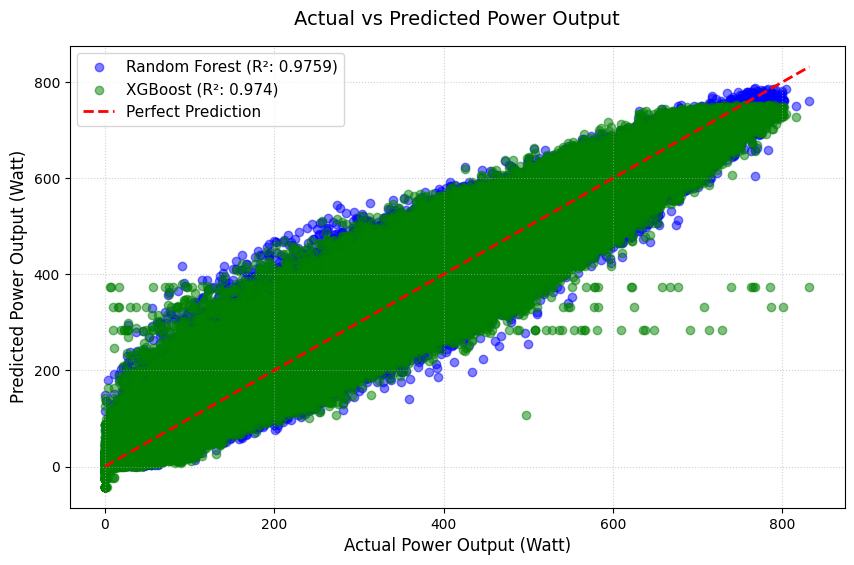

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, rf_test_pred, color='blue', alpha=0.5, label=f'Random Forest (R²: {rf_r2_test:.4f})')

plt.scatter(y_test, xgb_test_pred, color='green', alpha=0.5, label=f'XGBoost (R²: {xgb_r2_test:.4})')


max_val = max(max(y_test), max(rf_test_pred))
min_val = min(min(y_test), min(rf_test_pred))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Power Output', fontsize=14, pad=15)
plt.xlabel('Actual Power Output (Watt)', fontsize=12)
plt.ylabel('Predicted Power Output (Watt)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

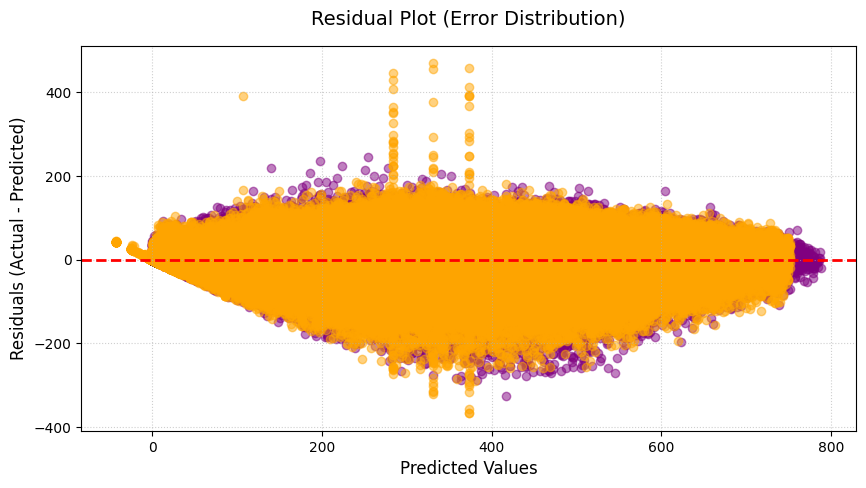

In [45]:
rf_residuals = y_test - rf_test_pred
xgb_residuals = y_test - xgb_test_pred

plt.figure(figsize=(10, 5))
plt.scatter(rf_test_pred, rf_residuals, color='purple', alpha=0.5)
plt.scatter(xgb_test_pred, xgb_residuals, color='orange', alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residual Plot (Error Distribution)', fontsize=14, pad=15)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

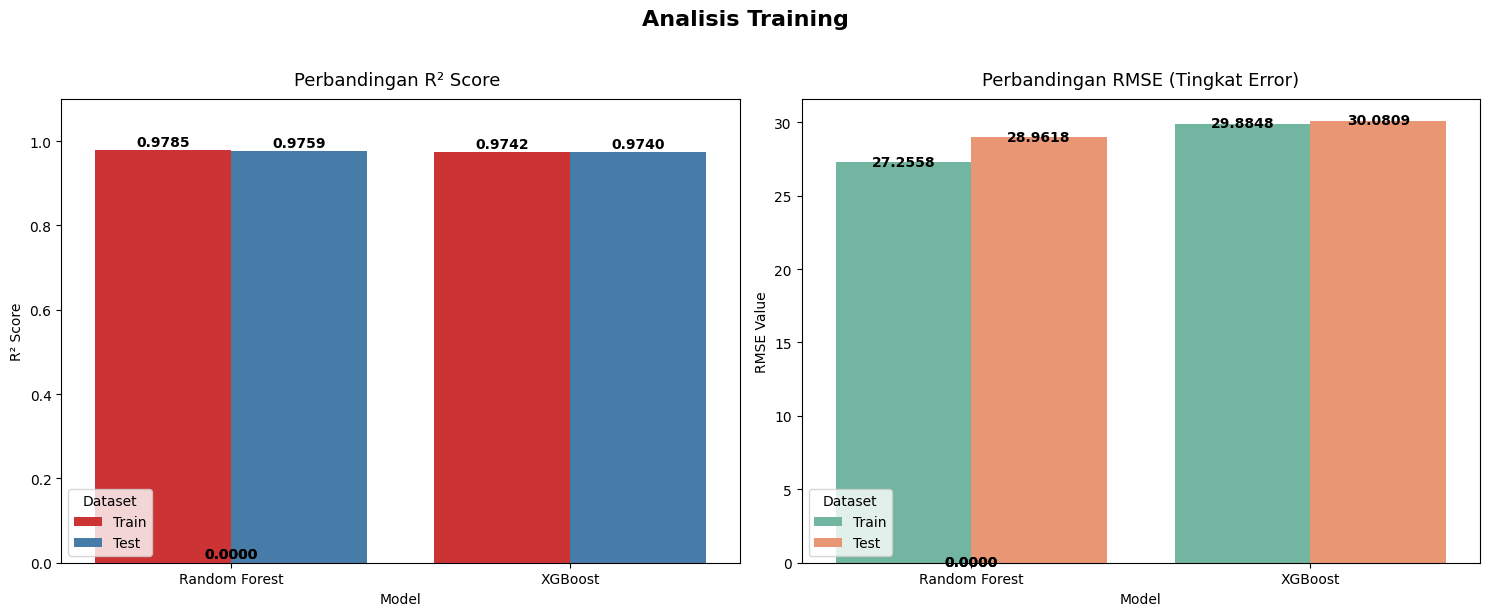

In [46]:

data_r2 = {
    'Model': ['Random Forest', 'Random Forest', 'XGBoost', 'XGBoost'],
    'Dataset': ['Train', 'Test', 'Train', 'Test'],
    'R2_Score': [rf_r2_train, rf_r2_test, xgb_r2_train, xgb_r2_test]
}
df_r2 = pd.DataFrame(data_r2)


data_rmse = {
    'Model': ['Random Forest', 'Random Forest', 'XGBoost', 'XGBoost'],
    'Dataset': ['Train', 'Test', 'Train', 'Test'],
    'RMSE': [rf_rmse_train, rf_rmse_test, xgb_rmse_train, xgb_rmse_test]
}
df_rmse = pd.DataFrame(data_rmse)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.barplot(x='Model', y='R2_Score', hue='Dataset', data=df_r2, ax=axes[0], palette='Set1')
axes[0].set_title('Perbandingan R² Score ', fontsize=13, pad=10)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', fontsize=10, fontweight='bold', color='black')


sns.barplot(x='Model', y='RMSE', hue='Dataset', data=df_rmse, ax=axes[1], palette='Set2')
axes[1].set_title('Perbandingan RMSE (Tingkat Error)', fontsize=13, pad=10)
axes[1].set_ylabel('RMSE Value')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.05),
                ha='center', va='center', fontsize=10, fontweight='bold', color='black')

plt.suptitle('Analisis Training', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 7. Inference

In [47]:
model_terpilih = joblib.load('solar_rf.joblib')
le = joblib.load('encoder_city.joblib')
scaler = joblib.load('scaler_data.joblib')
pca = joblib.load('pca_transformer.joblib')


input_baru = {
    'City': 'Mimika',
    'SolarIrradiance': 920.4,
    'SunHeight': 50.1,
    'Temperature': 33.5,
    'WindSpeed': 2.1
}


df_input = pd.DataFrame([input_baru])


df_input['City'] = le.transform(df_input['City'])


df_input_num = df_input[['SolarIrradiance', 'SunHeight', 'Temperature', 'WindSpeed']]

df_input_scaled = scaler.transform(df_input_num)
df_input_pca = pca.transform(df_input_scaled)


df_input_pca_terpilih = df_input_pca[:, :2]
df_input_pca_df = pd.DataFrame(df_input_pca_terpilih, columns=['PC1', 'PC2'])


df_input_final = pd.concat([df_input_pca_df, df_input['City'].to_frame()], axis=1)


hasil_estimasi = model_terpilih.predict(df_input_final)

print(f"Hasil Estimasi Daya Potensial: {hasil_estimasi[0]:.2f} Watt")

Hasil Estimasi Daya Potensial: 628.56 Watt
